In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline 

In [77]:
df=pd.read_csv("height_weight.csv")

In [8]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [ ]:
# df=df.drop("Gender",axis=1)

In [ ]:
# df=df.head(70)


In [28]:
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
65,65.279300,155.250421
66,68.274191,184.519391
67,72.765370,220.678041
68,68.099380,183.312655


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  24 non-null     int64
 1   Height  24 non-null     int64
dtypes: int64(2)
memory usage: 516.0 bytes


Text(0.5, 1.0, 'Height vs Weight')

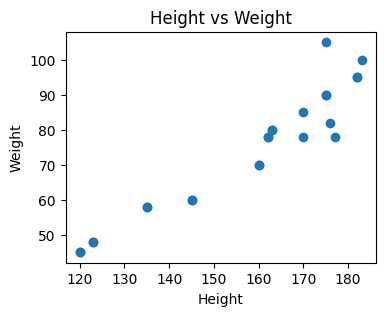

In [79]:
plt.figure(figsize=(4,3))
plt.scatter(df["Height"],df["Weight"])

plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Height vs Weight")

In [80]:
df.corr()

,Weight,Height
Weight,1.000000,0.952822
Height,0.952822,1.000000


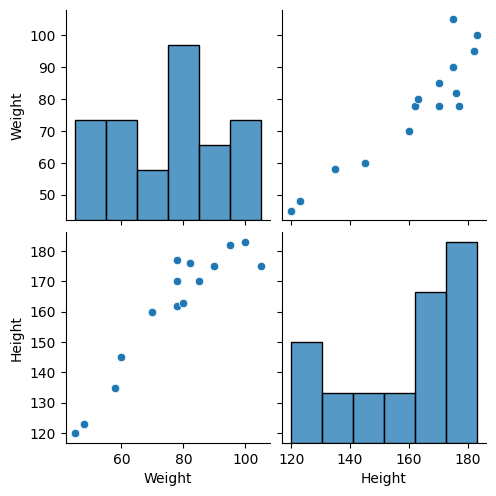

In [81]:
sns.pairplot(df)

##Dividing into indepedent and dependent feature

In [82]:
##Independent feature should be in 2D array or DataFrame and dependent feature should be in 1D array
X=df["Weight"]  ## creates series if single feature .SO ignore and unstead use double square brackets to create dataframe
X=df[["Weight"]]
# print(type(X))
# X
y=df["Height"]  ## can be in series as it is single feature
# print(type(y))

## Train test split

In [49]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 5.6 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.0 MB 3.1 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.0 MB 3.9 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.0 MB 4.5 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.0 MB 4.6 MB/s eta 0:00:01
   ------------------------------ --------- 6.0/8.0 MB 5.0 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.0 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 5.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   - -------------------------------------- 1.0/36.5 MB 6.3 MB/s eta 0:00:06
   -- ------------------------------------- 2.6/36.5 MB 6.9 MB/s eta 0:00:05
   ---- ----------------------------------- 4.2/36.5 MB 6.8 MB/s eta 0:00:05
   ------ ------------

In [83]:
import sklearn
print(f"Success! Scikit-learn version: {sklearn.__version__}")

Success! Scikit-learn version: 1.8.0


In [100]:

from  sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25)

In [101]:
X_train.shape

(18, 1)

## Standardisation

mean=0, 
standard_deviation=1

In [102]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [103]:
X_train=scaler.fit_transform(X_train)


In [104]:
X_test=scaler.transform(X_test)

In [105]:
X_test

array([[ 1.68729221],
       [ 1.39913984],
       [ 0.64994368],
       [-0.73318769],
       [ 1.11098747],
       [ 0.41942178]])

## apply simple linear regression

In [106]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [107]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [108]:
regression.coef_

array([19.26369737])

In [109]:
regression.intercept_

np.float64(152.94444444444446)

## plot bestfit line

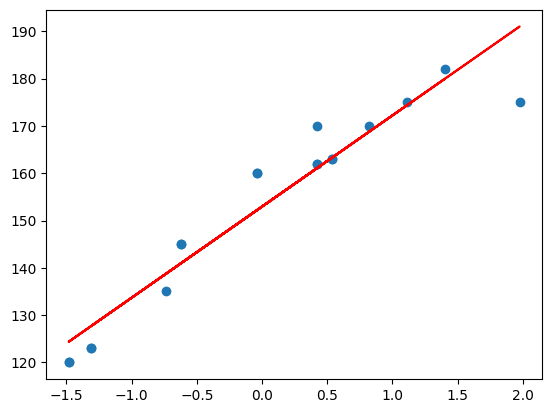

In [110]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train) ,color="red")

### Prediction of test data to test and check performance

y_pred_test=0.1106782(X_test)+48.39772733978784 //y=mx+c

In [111]:
y_pred=regression.predict(X_test)

In [112]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
r2=r2_score(y_test,y_pred)
print("R2 Score:",r2)
mse=mean_squared_error(y_test,y_pred)
print("Mean Squared Error:",mse)
mae=mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error:",mae)
rmse=np.sqrt(mse)
print("Root Mean Squared Error:",rmse)

R2 Score: 0.7607935511162209
Mean Squared Error: 65.27678205095127
Mean Absolute Error: 5.922737725475723
Root Mean Squared Error: 8.079404807963968


In [113]:
## adjusted r squared
adjusted_r2=1-(1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("Adjusted R2 Score:", adjusted_r2)

Adjusted R2 Score: 0.7009919388952761


## OLS linear regression

In [115]:
!pip install statsmodels
import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.5 MB 5.9 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.5 MB 6.2 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.5 MB 6.2 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.5 MB 6.2 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.5 MB 6.2 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.5 MB 1.8 MB/s eta 0:00:04
   ---------------- ----------------------- 3.9/9.5 MB 2.4 MB/s eta 0:00:03
   ----------------------- ---------------- 5.5/9.5 MB 3.0 MB/s eta 0:00:02
   --------------------------- ------------ 6.6/9.5 MB 3.2 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 3.9 MB/s eta 0:00:00

   ----------------------

In [116]:
prediction=model.predict(X_test)
print(prediction)

[ 32.50348642  26.95260639  12.5203183  -14.12390587  21.40172636
   8.07961427]


In [117]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.016
Model:                            OLS   Adj. R-squared (uncentered):             -0.042
Method:                 Least Squares   F-statistic:                             0.2693
Date:                Sun, 29 Mar 2026   Prob (F-statistic):                       0.610
Time:                        01:35:37   Log-Likelihood:                         -116.09
No. Observations:                  18   AIC:                                      234.2
Df Residuals:                      17   BIC:                                      235.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

## Prediction of new data

In [124]:
regression.predict(scaler.transform([[10]]))

c:\Users\krish\OneDrive\Desktop\DS&ML\basics\env1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([85.53209025])